# Effect of confound regression on graph-measure variability

## Combined population, Parkinson's disease, and healthy controls

This notebook compares graph-measure variability between the **no-confound-regression** and **with-confound-regression** pipelines. It generates six result figures—local and global metrics for PD+HC, PD, and HC—and three permutation-null diagnostic figures.

The visual system matches `Fig2and3.ipynb`: numerical variability (NV) is light gray, population variability (PV) is dark gray, and NPVR uses black for PD+HC, red for PD, and royal blue for HC. Stars denote mean NPVR and dashed lines connect threshold-wise means.

## Reproducibility

Python 3.11+ dependencies:

```bash
python -m pip install "numpy>=2" "pandas>=2" "matplotlib>=3.7" "scipy>=1.11"
```

Set `FMRI_DATA_ROOT` to `Allpop/Absolute_thresholding/MCA` or to the `Allpop` directory. The current project layout is discovered automatically, and both pipelines are calculated directly from the `table_corr*` pickles. Every plotting call saves PDF, PNG, and 300-dpi LZW-compressed TIFF files directly in `Fig5and6and-Conf_vs_NoConf/`.

In [1]:
from __future__ import annotations

import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.stats import permutation_test


THRESHOLDS = (0.05, 0.1, 0.2, 0.3, 0.4, 0.5)
THRESHOLD_LABELS = {0.05: "05", 0.1: "1", 0.2: "2", 0.3: "3", 0.4: "4", 0.5: "5"}

LOCAL_METRICS = {
    "degree": "Degree Centrality",
    "betweenness": "Betweenness Centrality",
    "eigenvector": "Eigenvector Centrality",
    "clustering": "Clustering Coefficient",
}
GLOBAL_METRICS = {
    "small_worldness": "Small-worldness",
    "average_shortest_path_length": "Average Shortest Path Length",
}
METRICS = {**LOCAL_METRICS, **GLOBAL_METRICS}
METRIC_COLUMNS = {
    "degree": "degree_centralities",
    "betweenness": "betweenness_centralities",
    "eigenvector": "eigenvector_centralities",
    "clustering": "clustering_coefficients",
    "small_worldness": "small_worldness",
    "average_shortest_path_length": "avg_shortest_path_length",
}

CSV_COLUMNS = {
    "degree": "degree",
    "betweenness": "betweeness",
    "eigenvector": "eigenvec",
    "clustering": "clusteringcoef",
    "small_worldness": "smallworldness",
    "average_shortest_path_length": "avg_shortestPathLength",
}
FRAME_TOKENS = CSV_COLUMNS.copy()

COLORS = {
    "numerical": "#B6B1B1",
    "population": "#353333",
    "combined": "black",
    "pd": "red",
    "hc": "royalblue",
}
GROUP_LABELS = {"combined": "PD+HC", "pd": "PD", "hc": "HC"}


def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    nested = Path(
        "overlap/allbatches/Allpop/pickles/"
        "Numerical-Variability-of-functional-MRI-Graph-Measures"
    )
    for base in (start, *start.parents):
        for candidate in (base, base / nested):
            if (candidate / "Fig5and6and-Conf_vs_NoConf/Fig5and6and-Conf_vs_NoConf.ipynb").is_file():
                return candidate
    raise FileNotFoundError("Could not locate the numerical-variability project.")


def find_data_root(repository_root: Path) -> Path:
    """Locate the Allpop directory from the MCA path or project layout."""
    if configured := os.environ.get("FMRI_DATA_ROOT"):
        candidate = Path(configured).expanduser().resolve()
        if not candidate.is_dir():
            raise FileNotFoundError(f"FMRI_DATA_ROOT does not exist: {candidate}")
        if (candidate / "table_corr0.05").is_dir():
            return candidate.parent.parent
        if (candidate / "Absolute_thresholding/MCA/table_corr0.05").is_dir():
            return candidate
        raise FileNotFoundError(
            f"FMRI_DATA_ROOT is neither MCA nor Allpop: {candidate}"
        )
    for base in (repository_root, *repository_root.parents):
        for candidate in (base, base / "overlap/allbatches/Allpop"):
            if (candidate / "Absolute_thresholding/MCA/table_corr0.05").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate Allpop/Absolute_thresholding/MCA.")


REPOSITORY_ROOT = find_repository_root()
ALLPOP_DIR = find_data_root(REPOSITORY_ROOT)
MCA_DATA_DIR = ALLPOP_DIR / "Absolute_thresholding" / "MCA"
VARIABILITY_DIR = ALLPOP_DIR / "pickles" / "pdhc"
FIGURE_DIR = REPOSITORY_ROOT / "Fig5and6and-Conf_vs_NoConf"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data:    {MCA_DATA_DIR}")
print(f"Figures: {FIGURE_DIR}")

Data:    /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/Absolute_thresholding/MCA
Figures: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf


## 1. Load and aggregate subject-level NPVR

The CSV files store squared regional or global terms. For each population and threshold, the group estimate is $\sqrt{|\operatorname{mean}(x)|}$, matching the original workflow.

In [2]:
BATCHES = (1, 2, 3, 4, 5)
EXCLUDED_ACQUISITIONS = {"acq-RLsplit1", "acq-LRsplit1"}
SESSION = "1"
ACQUISITION = "acq-RL"

exclusions_path = REPOSITORY_ROOT / "data" / "subject_exclusions.json"
if exclusions_path.is_file():
    import json
    exclusions = json.loads(exclusions_path.read_text(encoding="utf-8"))
else:
    exclusions = {"pd": [], "hc": []}
SUBJECT_EXCLUSIONS = {group: set(values) for group, values in exclusions.items()}


def threshold_directory(threshold: float) -> Path:
    directory = MCA_DATA_DIR / f"table_corr{threshold}"
    if not directory.is_dir():
        raise FileNotFoundError(f"Missing threshold directory: {directory}")
    return directory


def load_population_data(pipeline: str, threshold: float) -> dict[str, pd.DataFrame]:
    """Load PD, HC, and pooled raw graph metrics for one pipeline."""
    token = "WConf" if pipeline == "with" else "NoConf"
    directory = threshold_directory(threshold)
    pd_data = pd.concat(
        [pd.read_pickle(directory / f"Result_table{token}_batch_{batch}.pkl")
         for batch in BATCHES],
        ignore_index=True,
    )
    hc_data = pd.read_pickle(directory / f"Result_table{token}_batch_hc.pkl")
    pd_data = pd_data.loc[~pd_data["subject"].isin(SUBJECT_EXCLUSIONS["pd"])].copy()
    hc_data = hc_data.loc[~hc_data["subject"].isin(SUBJECT_EXCLUSIONS["hc"])].copy()
    return {
        "pd": pd_data,
        "hc": hc_data,
        "combined": pd.concat([pd_data, hc_data], ignore_index=True),
    }


population_data = {
    pipeline: {threshold: load_population_data(pipeline, threshold) for threshold in THRESHOLDS}
    for pipeline in ("with", "no")
}

sample_sizes = pd.DataFrame(
    {
        "threshold": threshold,
        "PD": population_data["with"][threshold]["pd"]["subject"].nunique(),
        "HC": population_data["with"][threshold]["hc"]["subject"].nunique(),
    }
    for threshold in THRESHOLDS
).set_index("threshold")
sample_sizes

,PD,HC
threshold,,
0.05,218,36
0.10,218,36
0.20,216,36
0.30,212,36
0.40,206,36
0.50,183,32


## 2. Compute pipeline differences

To preserve the paper analysis exactly, the original sign conventions are retained:

$$\Delta\mathrm{NPVR}=\mathrm{NPVR}_{\mathrm{no\ confound}}-\mathrm{NPVR}_{\mathrm{with\ confound}},$$

$$\Delta\mathrm{NV}=\mathrm{NV}_{\mathrm{with\ confound}}-\mathrm{NV}_{\mathrm{no\ confound}},\qquad
\Delta\mathrm{PV}=\mathrm{PV}_{\mathrm{with\ confound}}-\mathrm{PV}_{\mathrm{no\ confound}}.$$

The combined-population differences come from the pipeline's saved `difference_data.pkl`; PD and HC differences are reconstructed from their group files.

In [3]:
def metric_values(group: pd.DataFrame, source_column: str) -> np.ndarray:
    values = []
    for value in group[source_column]:
        if isinstance(value, dict):
            value = list(value.values())
        values.append(np.asarray(value, dtype=float))
    return np.asarray(values, dtype=float)


def calculate_group_variances(
    data: pd.DataFrame, group_columns: list[str], *, unique_subjects: bool = False
) -> pd.DataFrame:
    filtered = data.loc[~data["acquisition"].isin(EXCLUDED_ACQUISITIONS)].copy()
    rows = []
    for keys, group in filtered.groupby(group_columns, sort=True):
        if unique_subjects:
            group = group.drop_duplicates("subject")
        if len(group) < 2:
            continue
        keys = keys if isinstance(keys, tuple) else (keys,)
        result = dict(zip(group_columns, keys))
        for metric, source_column in METRIC_COLUMNS.items():
            result[metric] = np.var(metric_values(group, source_column), axis=0)
        rows.append(result)
    return pd.DataFrame(rows)


def root_mean_variance(variance_data: pd.DataFrame) -> dict[str, np.ndarray | float]:
    selected = variance_data.loc[
        (variance_data["session"].astype(str) == SESSION)
        & (variance_data["acquisition"] == ACQUISITION)
    ]
    if selected.empty:
        raise ValueError(f"No rows for session={SESSION}, acquisition={ACQUISITION}")
    result = {}
    for metric in METRICS:
        value = np.sqrt(np.mean(np.stack(selected[metric].to_numpy()), axis=0))
        result[metric] = float(value) if value.ndim == 0 else value
    return result


def estimate_variability(data: pd.DataFrame) -> dict[str, dict[str, np.ndarray | float]]:
    numerical = calculate_group_variances(data, ["subject", "session", "acquisition"])
    population = calculate_group_variances(
        data, ["repetition", "session", "acquisition"], unique_subjects=True
    )
    return {
        "numerical": root_mean_variance(numerical),
        "population": root_mean_variance(population),
    }


def safe_ratio(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.divide(
            numerator, denominator, out=np.full_like(numerator, np.nan),
            where=denominator != 0,
        )
    return float(ratio) if ratio.ndim == 0 else ratio


variability_by_pipeline = {
    pipeline: {
        group: {
            threshold: estimate_variability(population_data[pipeline][threshold][group])
            for threshold in THRESHOLDS
        }
        for group in ("combined", "pd", "hc")
    }
    for pipeline in ("with", "no")
}

npvr_by_pipeline = {
    pipeline: {
        group: {
            threshold: {
                metric: safe_ratio(
                    variability_by_pipeline[pipeline][group][threshold]["numerical"][metric],
                    variability_by_pipeline[pipeline][group][threshold]["population"][metric],
                )
                for metric in METRICS
            }
            for threshold in THRESHOLDS
        }
        for group in ("combined", "pd", "hc")
    }
    for pipeline in ("with", "no")
}


def subtract_metrics(first: dict, second: dict) -> dict:
    return {
        metric: np.asarray(first[metric], dtype=float) - np.asarray(second[metric], dtype=float)
        for metric in METRICS
    }


npvr_difference = {
    group: {
        threshold: subtract_metrics(
            npvr_by_pipeline["no"][group][threshold],
            npvr_by_pipeline["with"][group][threshold],
        )
        for threshold in THRESHOLDS
    }
    for group in ("combined", "pd", "hc")
}

In [4]:
variability_difference = {
    group: {
        threshold: {
            kind: subtract_metrics(
                variability_by_pipeline["no"][group][threshold][kind],
                variability_by_pipeline["with"][group][threshold][kind],
            )
            for kind in ("numerical", "population")
        }
        for threshold in THRESHOLDS
    }
    for group in ("combined", "pd", "hc")
}

print("Computed pooled PD+HC, PD, and HC NV, PV, and NPVR differences at six thresholds.")

Computed pooled PD+HC, PD, and HC NV, PV, and NPVR differences at six thresholds.


## 3. One-sample permutation inference

For every local metric, threshold, and population, a one-sample sign-flip permutation test evaluates whether the regional mean difference is below zero. The 24 tests within each population are Bonferroni-corrected. A fixed random seed reproduces the original analysis.

In [5]:
def run_permutation_analysis(group: str) -> dict:
    raw_p_values, results = [], {}
    for threshold in THRESHOLDS:
        results[threshold] = {}
        for metric in LOCAL_METRICS:
            values = np.asarray(npvr_difference[group][threshold][metric], dtype=float)
            result = permutation_test(
                (values,), np.mean, permutation_type="samples", vectorized=True,
                alternative="less", random_state=1, axis=0,
            )
            raw_p_values.append(float(result.pvalue))
            results[threshold][metric] = {
                "statistic": float(result.statistic),
                "null": np.asarray(result.null_distribution, dtype=float),
            }

    corrected = np.minimum(np.asarray(raw_p_values) * len(raw_p_values), 1.0)
    index = 0
    for threshold in THRESHOLDS:
        for metric in LOCAL_METRICS:
            results[threshold][metric]["p_corrected"] = float(corrected[index])
            index += 1
    return results


permutation_results = {
    group: run_permutation_analysis(group) for group in ("combined", "pd", "hc")
}

permutation_table = pd.DataFrame(
    {
        "population": GROUP_LABELS[group], "threshold": threshold,
        "metric": LOCAL_METRICS[metric],
        "mean_difference": result["statistic"],
        "p_bonferroni": result["p_corrected"],
    }
    for group, group_results in permutation_results.items()
    for threshold, threshold_results in group_results.items()
    for metric, result in threshold_results.items()
)
permutation_table.round(4)

,population,threshold,metric,mean_difference,p_bonferroni
0,PD+HC,0.05,Degree Centrality,-0.0204,0.0024
1,PD+HC,0.05,Betweenness Centrality,-0.0091,0.0024
2,PD+HC,0.05,Eigenvector Centrality,-0.0354,0.0024
3,PD+HC,0.05,Clustering Coefficient,-0.0140,0.0024
4,PD+HC,0.10,Degree Centrality,-0.0089,0.0192
...,...,...,...,...,...
67,HC,0.40,Clustering Coefficient,-0.0133,0.0192
68,HC,0.50,Degree Centrality,-0.0216,0.0024
69,HC,0.50,Betweenness Centrality,-0.0234,0.0528
70,HC,0.50,Eigenvector Centrality,-0.0334,0.0024


## 4. Figure style and export helpers

All result figures use the same dimensions, metric order, axis language, gray NV/PV palette, group colors, threshold labels, and bottom captions as `Fig2and3.ipynb`.

In [55]:
def finite_values(value) -> np.ndarray:
    values = np.asarray(value, dtype=float).reshape(-1)
    return values[np.isfinite(values)]


def regional_mean(value) -> float:
    return float(np.nanmean(finite_values(value)))


def significance_label(p_value: float) -> str:
    if p_value < 0.001: return "***"
    if p_value < 0.01: return "**"
    if p_value < 0.05: return "*"
    return "ns"


def draw_box(axis, values, position, color, width=0.20) -> None:
    values = finite_values(values)
    parts = axis.boxplot(
        [values], positions=[position], widths=width, patch_artist=True,
        showfliers=False, manage_ticks=False,
    )
    parts["boxes"][0].set(facecolor=to_rgba(color, 0.35), edgecolor=color, linewidth=1.2)
    for element in ("whiskers", "caps", "medians"):
        plt.setp(parts[element], color=color, linewidth=1.0)
    jitter = np.linspace(-0.035, 0.035, len(values))
    axis.scatter(position + jitter, values, s=7, color=color, alpha=0.45, edgecolors="none")


def save_figure(figure: plt.Figure, stem: str) -> None:
    """Save PDF, PNG preview, and 300-dpi LZW-compressed TIFF."""
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    png_path = FIGURE_DIR / f"{stem}.png"
    tif_path = FIGURE_DIR / f"{stem}.tif"
    figure.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
    figure.savefig(png_path, format="png", dpi=180, bbox_inches="tight")
    figure.savefig(
        tif_path, format="tiff", dpi=300, bbox_inches="tight",
        pil_kwargs={"compression": "tiff_lzw"},
    )
    print(f"Generated TIFF: {tif_path}")


def add_combined_caption(figure: plt.Figure, y=0.01) -> None:
    handles = [
        Line2D([0], [0], color=COLORS[group], marker="*", linestyle="--",
               markersize=10, label=f"{GROUP_LABELS[group]}: Mean NPVR difference")
        for group in ("combined", "pd", "hc")
    ]
    figure.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, y),
                  ncol=3, frameon=False)


def add_group_caption(figure: plt.Figure, group: str, y=0.01,
                      numerical_color: str | None = None,
                      population_color: str | None = None) -> None:
    numerical_color = numerical_color or COLORS["numerical"]
    population_color = population_color or COLORS["population"]
    handles = [
        Patch(facecolor="none", edgecolor="none", label=f"Group: {GROUP_LABELS[group]}"),
        Patch(facecolor=to_rgba(numerical_color, 0.35), edgecolor=numerical_color,
              label=r"NV difference ($\Delta\sigma_{num}$)"),
        Patch(facecolor=to_rgba(population_color, 0.35), edgecolor=population_color,
              label=r"PV difference ($\Delta\sigma_{pop}$)"),
        Patch(facecolor=to_rgba(COLORS[group], 0.35), edgecolor=COLORS[group],
              label=r"NPVR difference ($\Delta$NPVR)"),
        Line2D([0], [0], color=COLORS[group], marker="*", linestyle="--",
               markersize=10, markeredgecolor="black", label="Mean NPVR difference"),
    ]
    figure.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, y),
                  ncol=5, frameon=False)

## 5. Combined PD+HC, PD, and HC NPVR differences

Regional distributions are shown for local metrics; global metrics are scalar threshold-wise trends.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-localPD+HC.tif


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

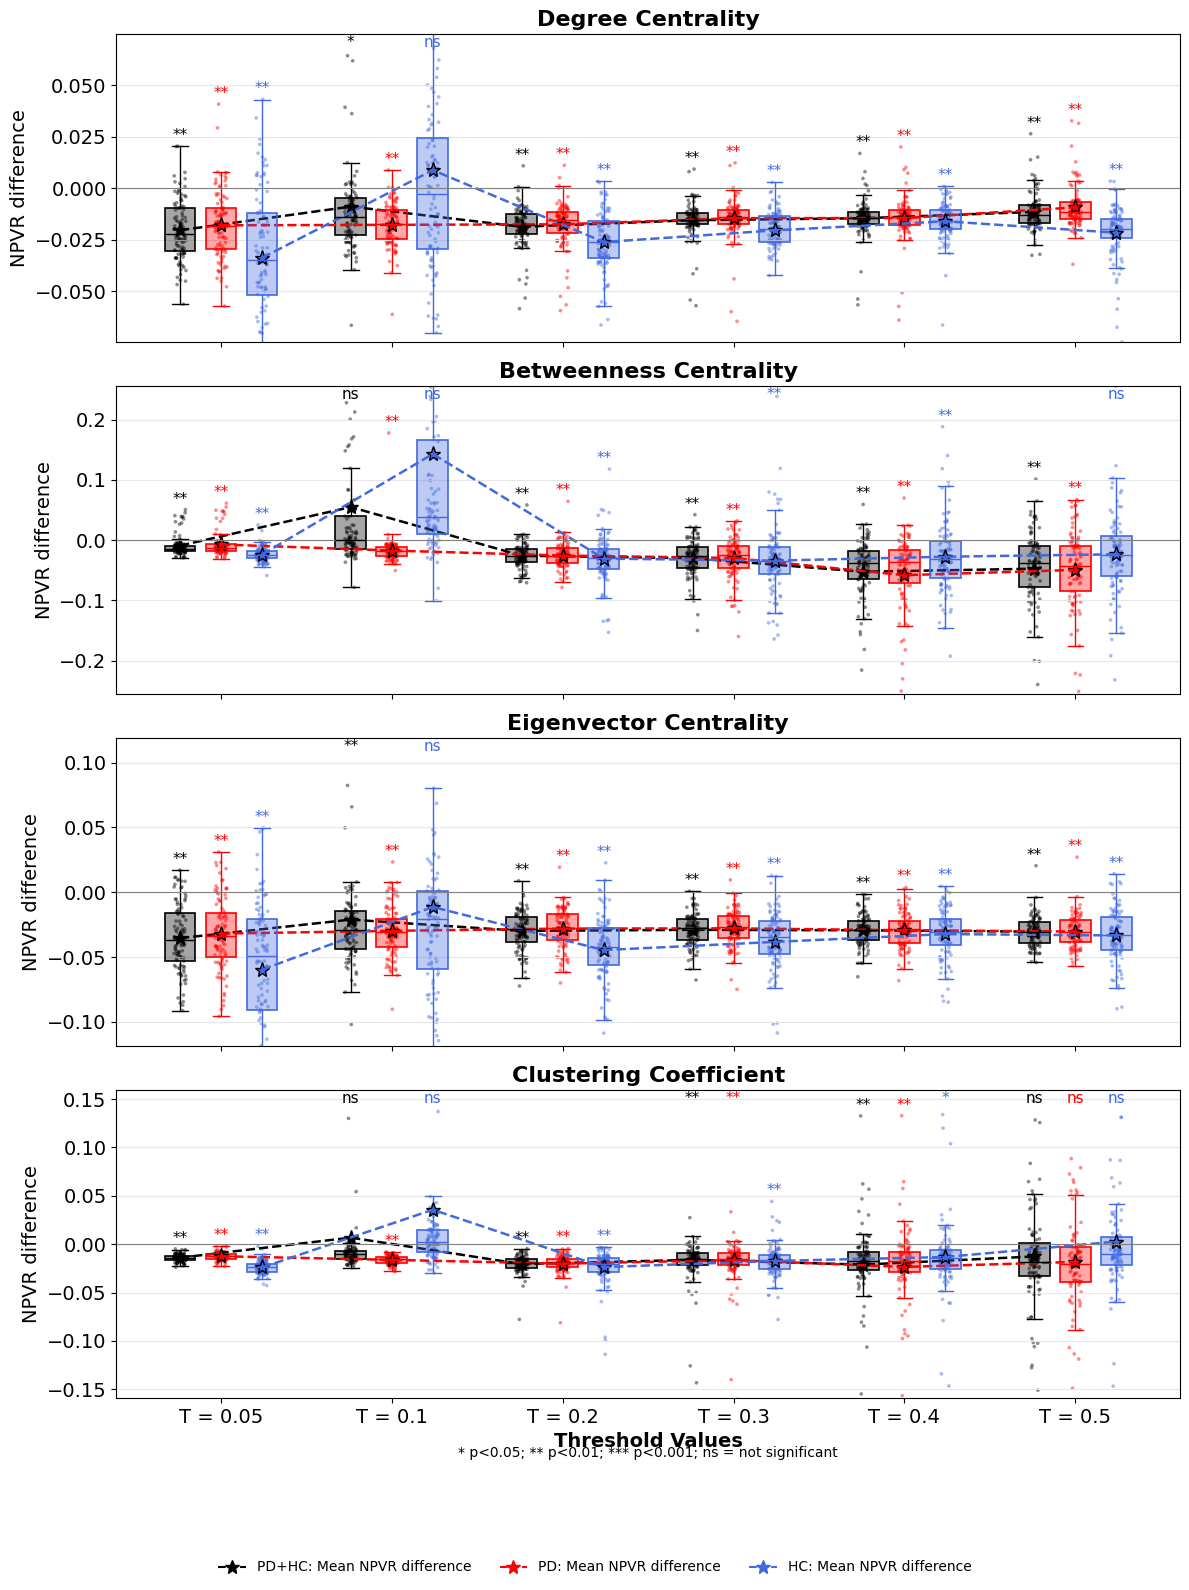

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-globalPD+HC.tif


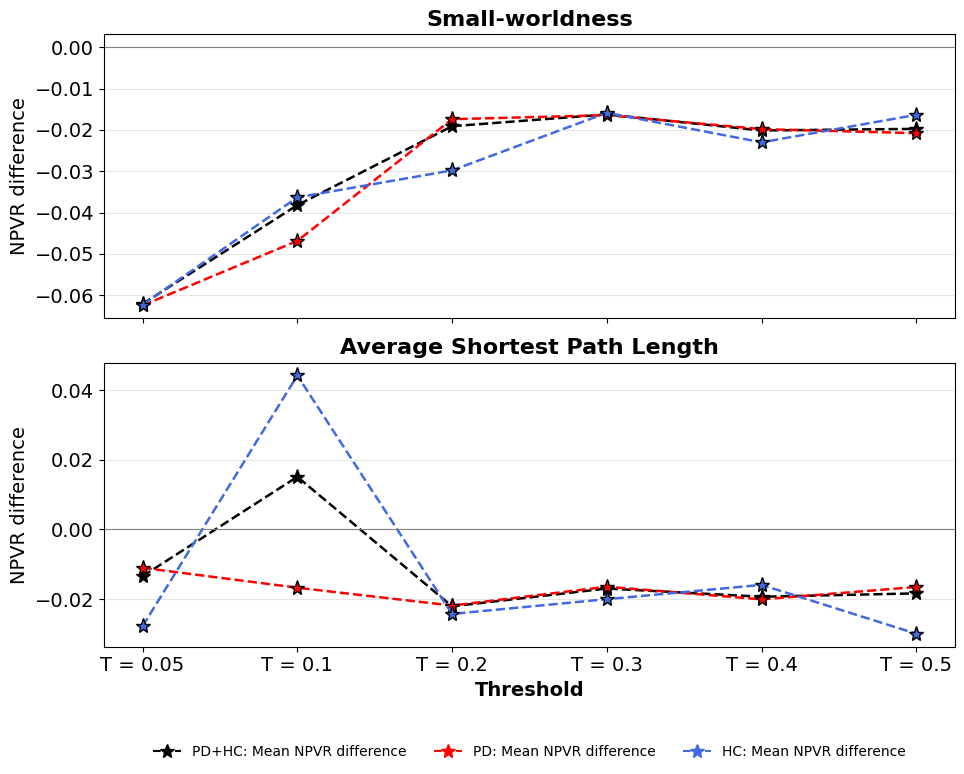

In [62]:
def plot_combined_local() -> plt.Figure:

    figure, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
    x = np.arange(len(THRESHOLDS), dtype=float)
    offsets = {"combined": -0.24, "pd": 0.0, "hc": 0.24}

    for axis, (metric, label) in zip(axes, LOCAL_METRICS.items()):
        all_values = [finite_values(npvr_difference[g][t][metric]) for g in offsets for t in THRESHOLDS]
        combined_values = np.concatenate(all_values)
        limit = np.percentile(np.abs(combined_values), 97.5) * 1.20
        if limit == 0:
            limit = 1.0
        axis.set_ylim(-limit, limit)
        for group, offset in offsets.items():
            means = []
            for index, threshold in enumerate(THRESHOLDS):
                values = npvr_difference[group][threshold][metric]
                position = x[index] + offset
                draw_box(axis, values, position, COLORS[group], width=0.18)
                mean = regional_mean(values)
                means.append(mean)
                axis.plot(position, mean, marker="*", markersize=11, color=COLORS[group],
                          markeredgecolor="black", linestyle="None")
                p_value = permutation_results[group][threshold][metric]["p_corrected"]
                axis.text(position, min(max(finite_values(values)) + 0.04 * limit, 0.92 * limit),
                          significance_label(p_value), ha="center", color=COLORS[group], fontsize=11)
            axis.plot(x + offset, means, color=COLORS[group], linestyle="--", linewidth=1.8)
        axis.axhline(0, color="gray", linewidth=0.8)
        axis.set_title(label, fontweight="bold", fontsize=16)
        axis.set_ylabel("NPVR difference", fontsize=14)
        axis.tick_params(axis="both", labelsize=14)
        axis.grid(axis="y", color="0.9", linewidth=0.8)

    axes[-1].set_xticks(x, [f"T = {t:g}" for t in THRESHOLDS])
    axes[-1].set_xlabel("Threshold Values", fontweight="bold", fontsize=14)
    axes[-1].text(0.5, -0.19, "* p<0.05; ** p<0.01; *** p<0.001; ns = not significant",
                  transform=axes[-1].transAxes, ha="center", fontsize=10)
    add_combined_caption(figure, 0.005)
    figure.tight_layout(rect=(0, 0.08, 1, 1))
    return figure


def plot_combined_global() -> plt.Figure:
    figure, axes = plt.subplots(2, 1, figsize=(16,8), sharex=True)
    x = np.arange(len(THRESHOLDS), dtype=float)
    for axis, (metric, label) in zip(axes, GLOBAL_METRICS.items()):
        for group in ("combined", "pd", "hc"):
            values = [float(npvr_difference[group][t][metric]) for t in THRESHOLDS]
            axis.plot(x, values, color=COLORS[group], marker="*", markersize=11,
                      linestyle="--", linewidth=1.8, markeredgecolor="black")
        axis.axhline(0, color="gray", linewidth=0.8)
        axis.set_title(label, fontweight="bold", fontsize=16)
        axis.set_ylabel("NPVR difference", fontsize=14)
        axis.tick_params(axis="both", labelsize=14)
        axis.grid(axis="y", color="0.9", linewidth=0.8)
    axes[-1].set_xticks(x, [f"T = {t:g}" for t in THRESHOLDS])
    axes[-1].set_xlabel("Threshold", fontweight="bold", fontsize=14)
    figure.tight_layout(rect=(0, 0.10, 1, 1))
    figure.subplots_adjust(right=0.6)
    caption_x = (figure.subplotpars.left + figure.subplotpars.right) / 2
    add_combined_caption(figure, 0.03)
    figure.legends[-1].set_bbox_to_anchor(
        (caption_x, 0.03), transform=figure.transFigure
    )

    return figure


combined_local = plot_combined_local()
save_figure(combined_local, "fig5-localPD+HC")
plt.show()

combined_global = plot_combined_global()
save_figure(combined_global, "fig5-globalPD+HC")
plt.show()

### Additional local figure — mean NPVR stars only

This version removes the regional NPVR boxplots and points. Each star is the regional mean NPVR difference; dashed lines connect thresholds and the colored label above each star reports Bonferroni-corrected significance.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-localPD+HC-stars-only.tif


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

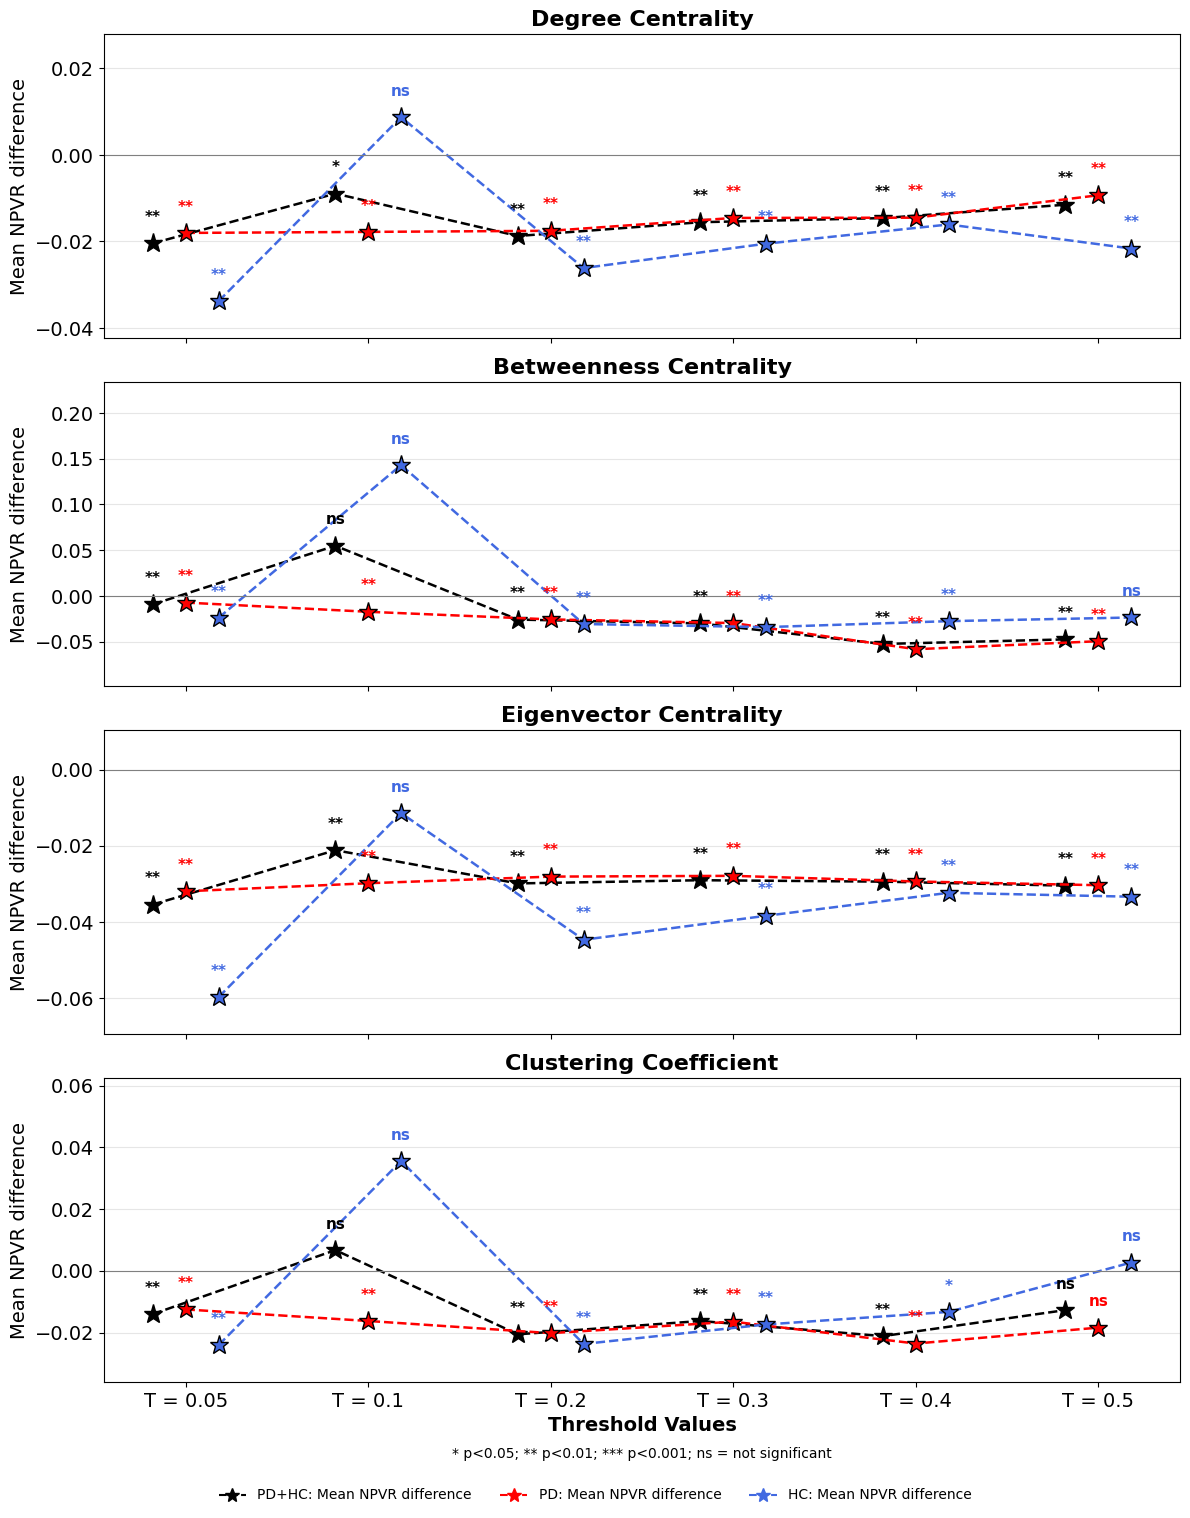

In [58]:
def plot_combined_local_means_only() -> plt.Figure:
    """Plot only the regional mean NPVR-difference stars."""
    figure, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
    x = np.arange(len(THRESHOLDS), dtype=float)
    offsets = {"combined": -0.18, "pd": 0.0, "hc": 0.18}

    for axis, (metric, label) in zip(axes, LOCAL_METRICS.items()):
        group_means = {
            group: [
                regional_mean(npvr_difference[group][threshold][metric])
                for threshold in THRESHOLDS
            ]
            for group in offsets
        }
        all_means = np.concatenate([np.asarray(values) for values in group_means.values()])
        span = max(np.ptp(all_means), 0.20 * np.max(np.abs(all_means)), 1e-4)
        axis.set_ylim(np.min(all_means) - 0.20 * span, np.max(all_means) + 0.45 * span)

        for group, offset in offsets.items():
            means = group_means[group]
            axis.plot(
                x + offset, means, linestyle="--", linewidth=1.8, marker="*",
                markersize=14, color=COLORS[group], markeredgecolor="black",
            )
            for index, threshold in enumerate(THRESHOLDS):
                p_value = permutation_results[group][threshold][metric]["p_corrected"]
                axis.text(
                    x[index] + offset, means[index] + 0.10 * span,
                    significance_label(p_value), ha="center", va="bottom",
                    color=COLORS[group], fontsize=11, fontweight="bold",
                )

        axis.axhline(0, color="gray", linewidth=0.8)
        axis.set_title(label, fontweight="bold", fontsize=16)
        axis.set_ylabel("Mean NPVR difference", fontsize=14)
        axis.tick_params(axis="both", labelsize=14)
        axis.grid(axis="y", color="0.9", linewidth=0.8)

    axes[-1].set_xticks(x, [f"T = {threshold:g}" for threshold in THRESHOLDS])
    axes[-1].set_xlabel("Threshold Values", fontweight="bold", fontsize=14)
    axes[-1].text(
        0.5, -0.25, "* p<0.05; ** p<0.01; *** p<0.001; ns = not significant",
        transform=axes[-1].transAxes, ha="center", fontsize=10,
    )
    add_combined_caption(figure, 0.05)
    figure.tight_layout(rect=(0, 0.08, 1, 1))
    return figure


combined_local_means_only = plot_combined_local_means_only()
save_figure(combined_local_means_only, "fig5-localPD+HC-stars-only")
plt.show()

## 6. PD and HC local variability and NPVR differences

NV and PV use the left axis; regional NPVR differences and their means use the right axis.

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-localpooledPD+HC.tif


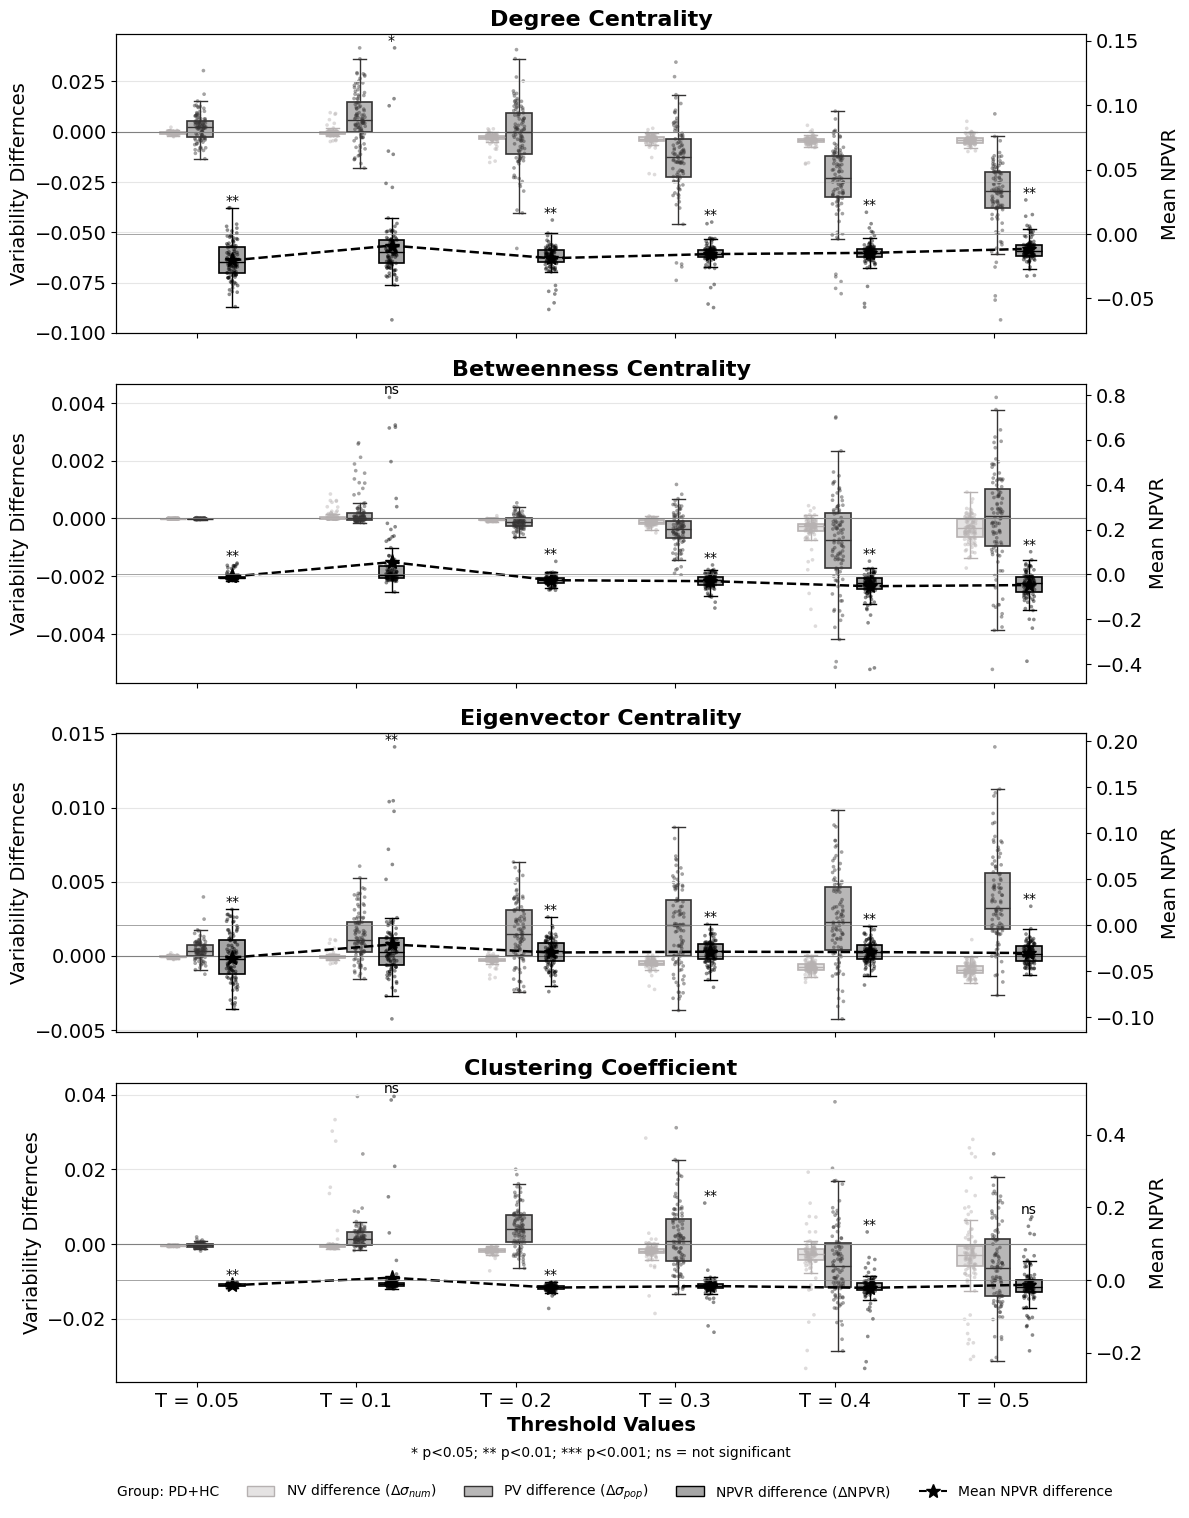

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-localpd.tif


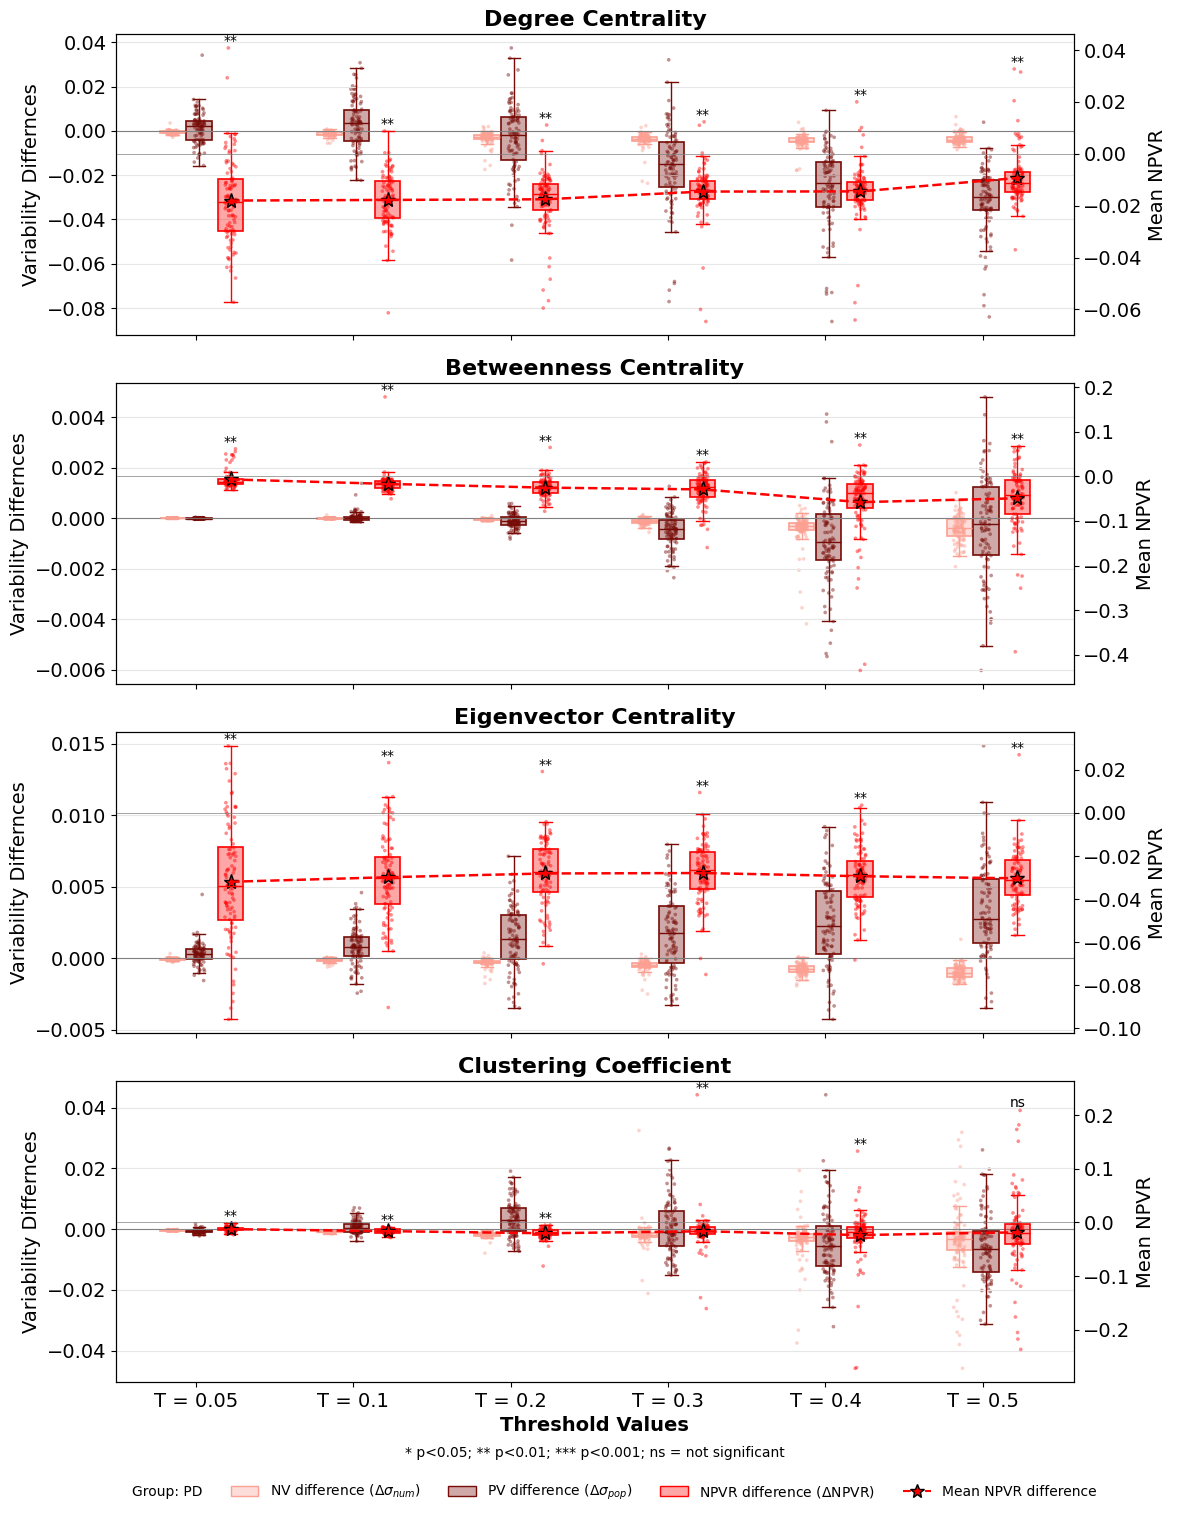

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-localhhc.tif


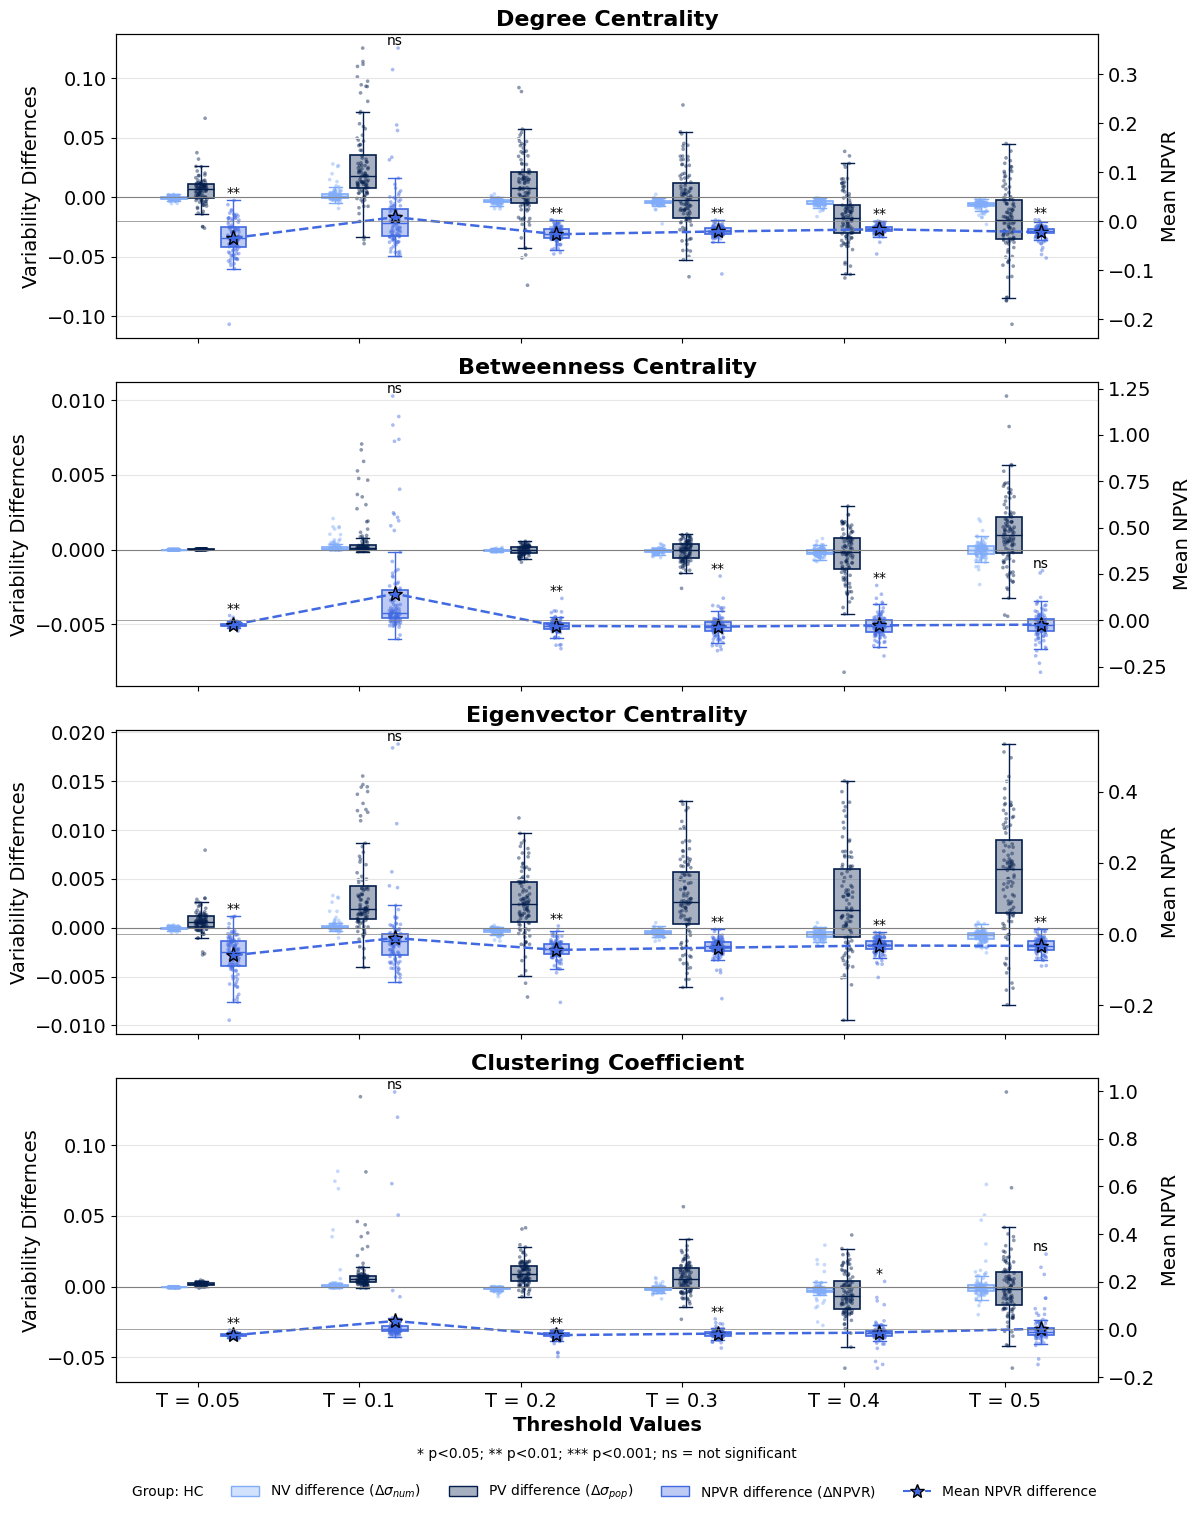

In [9]:
def plot_group_local(group: str, numerical_color: str, population_color: str) -> plt.Figure:
    figure, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
    x = np.arange(len(THRESHOLDS), dtype=float)
    for axis, (metric, label) in zip(axes, LOCAL_METRICS.items()):
        ratio_axis = axis.twinx()
        means = []
        for index, threshold in enumerate(THRESHOLDS):
            numerical = variability_difference[group][threshold]["numerical"][metric]
            population = variability_difference[group][threshold]["population"][metric]
            ratio = npvr_difference[group][threshold][metric]
            draw_box(axis, numerical, x[index] - 0.15, color=numerical_color, width=0.16)
            draw_box(axis, population, x[index] + 0.02, color=population_color, width=0.16)
            draw_box(ratio_axis, ratio, x[index] + 0.22, COLORS[group], width=0.16)
            mean = regional_mean(ratio)
            means.append(mean)
            ratio_axis.plot(x[index] + 0.22, mean, marker="*", markersize=11,
                            color=COLORS[group], markeredgecolor="black")
            p_value = permutation_results[group][threshold][metric]["p_corrected"]
            ratio_axis.text(x[index] + 0.22, max(finite_values(ratio)), significance_label(p_value),
                            ha="center", va="bottom", fontsize=10)
        ratio_axis.plot(x + 0.22, means, color=COLORS[group], linestyle="--", linewidth=1.8)
        axis.axhline(0, color="gray", linewidth=0.8)
        ratio_axis.axhline(0, color="gray", linewidth=0.5)
        axis.set_title(label, fontweight="bold", fontsize=16)
        axis.set_ylabel("Variability Differnces", fontsize=14)
        ratio_axis.set_ylabel("Mean NPVR", fontsize=14)
        axis.tick_params(axis="both", labelsize=14)
        ratio_axis.tick_params(axis="y", labelsize=14)
        axis.grid(axis="y", color="0.9", linewidth=0.8)
    axes[-1].set_xticks(x, [f"T = {t:g}" for t in THRESHOLDS])
    axes[-1].set_xlabel("Threshold Values", fontweight="bold", fontsize=14)
    axes[-1].text(0.5, -0.25, "* p<0.05; ** p<0.01; *** p<0.001; ns = not significant",
                  transform=axes[-1].transAxes, ha="center", fontsize=10)
    add_group_caption(figure, group, 0.05, numerical_color, population_color)
    figure.tight_layout(rect=(0, 0.08, 1, 1))
    return figure


pooled_local = plot_group_local("combined", numerical_color=COLORS["numerical"], population_color=COLORS["population"])
save_figure(pooled_local, "fig5-localpooledPD+HC")
plt.show()

pd_local = plot_group_local("pd", numerical_color="#FBA092", population_color="#770B07")
save_figure(pd_local, "fig5-localpd")
plt.show()

hc_local = plot_group_local("hc", numerical_color="#80ACF9", population_color="#031E4D")
save_figure(hc_local, "fig5-localhhc")
plt.show()

## 7. PD and HC global variability and NPVR differences

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-globalpooledPD+HC.tif


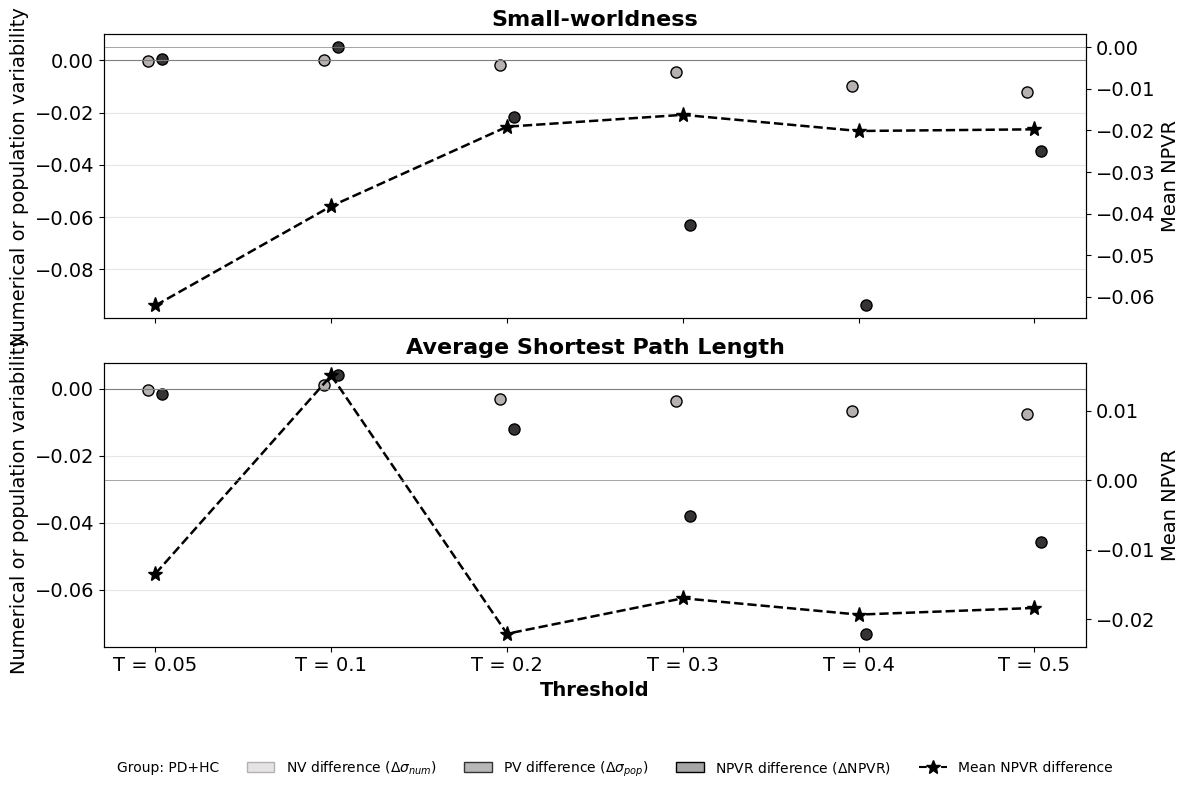

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-globalhpd.tif


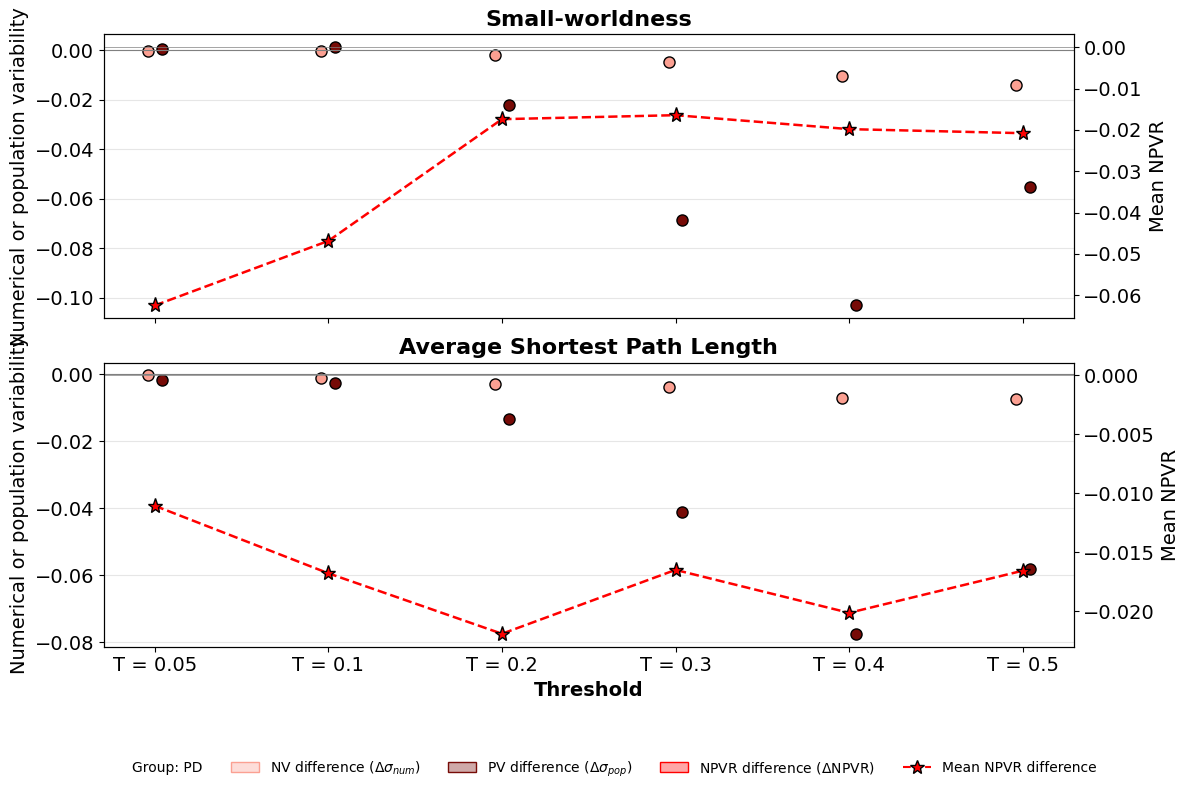

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/fig5-globalhhc.tif


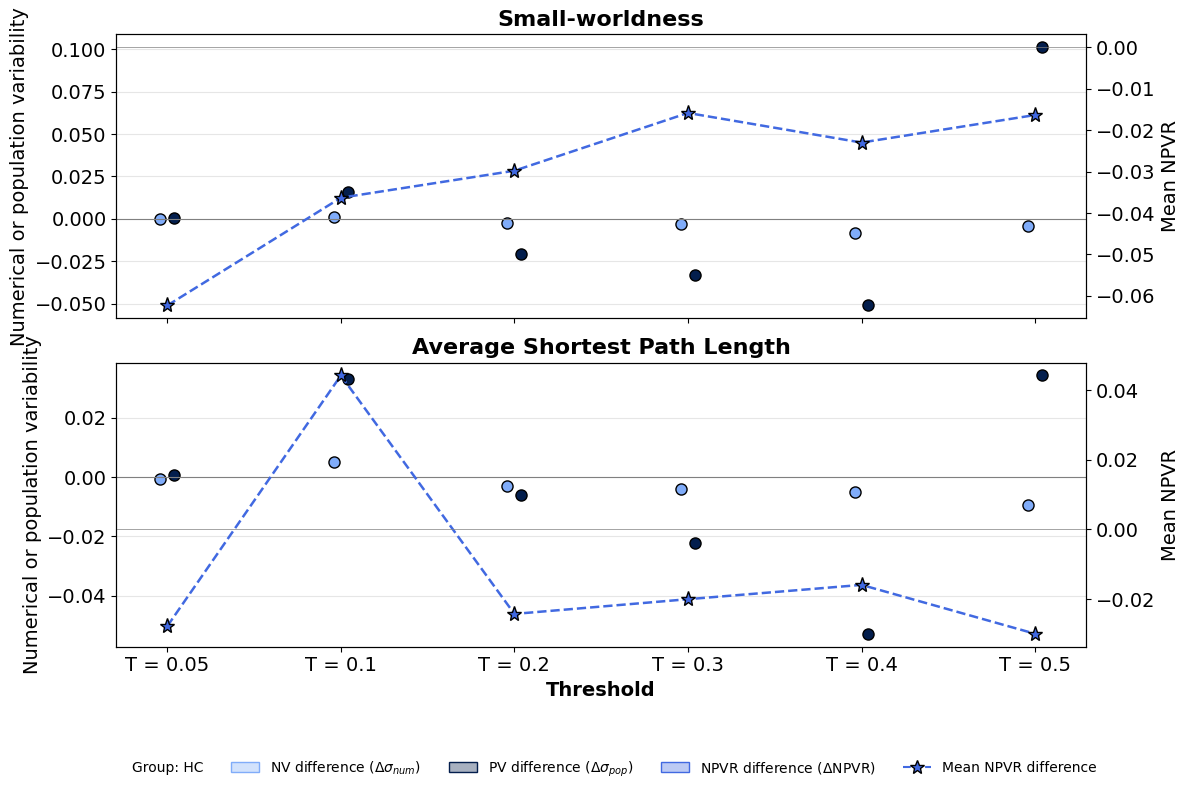

In [10]:
def plot_group_global(group: str, numerical_color: str, population_color: str) -> plt.Figure:
    figure, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    x = np.arange(len(THRESHOLDS), dtype=float)
    for axis, (metric, label) in zip(axes, GLOBAL_METRICS.items()):
        numerical = [float(variability_difference[group][t]["numerical"][metric]) for t in THRESHOLDS]
        population = [float(variability_difference[group][t]["population"][metric]) for t in THRESHOLDS]
        ratio = [float(npvr_difference[group][t][metric]) for t in THRESHOLDS]
        axis.plot(x - 0.04, numerical, color=numerical_color, marker="o",
                  markeredgecolor="black", markersize=8, linestyle="None")
        axis.plot(x + 0.04, population, color=population_color, marker="o",
                  markeredgecolor="black", markersize=8, linestyle="None")
        ratio_axis = axis.twinx()
        ratio_axis.plot(x, ratio, color=COLORS[group], marker="*", markersize=11,
                        markeredgecolor="black", linestyle="--", linewidth=1.8)
        axis.axhline(0, color="gray", linewidth=0.8)
        ratio_axis.axhline(0, color="gray", linewidth=0.5)
        axis.set_title(label, fontweight="bold", fontsize=16)
        axis.set_ylabel("Numerical or population variability", fontsize=14)
        ratio_axis.set_ylabel("Mean NPVR", fontsize=14)
        axis.tick_params(axis="both", labelsize=14)
        ratio_axis.tick_params(axis="y", labelsize=14)
        axis.grid(axis="y", color="0.9", linewidth=0.8)
    axes[-1].set_xticks(x, [f"T = {t:g}" for t in THRESHOLDS])
    axes[-1].set_xlabel("Threshold", fontweight="bold", fontsize=14)
    add_group_caption(figure, group, 0.005, numerical_color, population_color)
    figure.tight_layout(rect=(0, 0.10, 1, 1))
    return figure


pooled_global = plot_group_global("combined", numerical_color=COLORS["numerical"], population_color=COLORS["population"])
save_figure(pooled_global, "fig5-globalpooledPD+HC")
plt.show()

pd_global = plot_group_global("pd", numerical_color="#FBA092", population_color="#770B07")
save_figure(pd_global, "fig5-globalhpd")
plt.show()

hc_global = plot_group_global("hc", numerical_color="#80ACF9", population_color="#031E4D")
save_figure(hc_global, "fig5-globalhhc")
plt.show()

### Parkinson's disease
![PD global variability and NPVR differences](Figures/fig5-globalhpd.png)

### Healthy controls
![HC global variability and NPVR differences](Figures/fig5-globalhhc.png)

## 8. Permutation-null diagnostics

The gray histograms show the sign-flip null distributions; the colored dashed line is the observed regional mean difference.

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/permutation-null-combined.tif


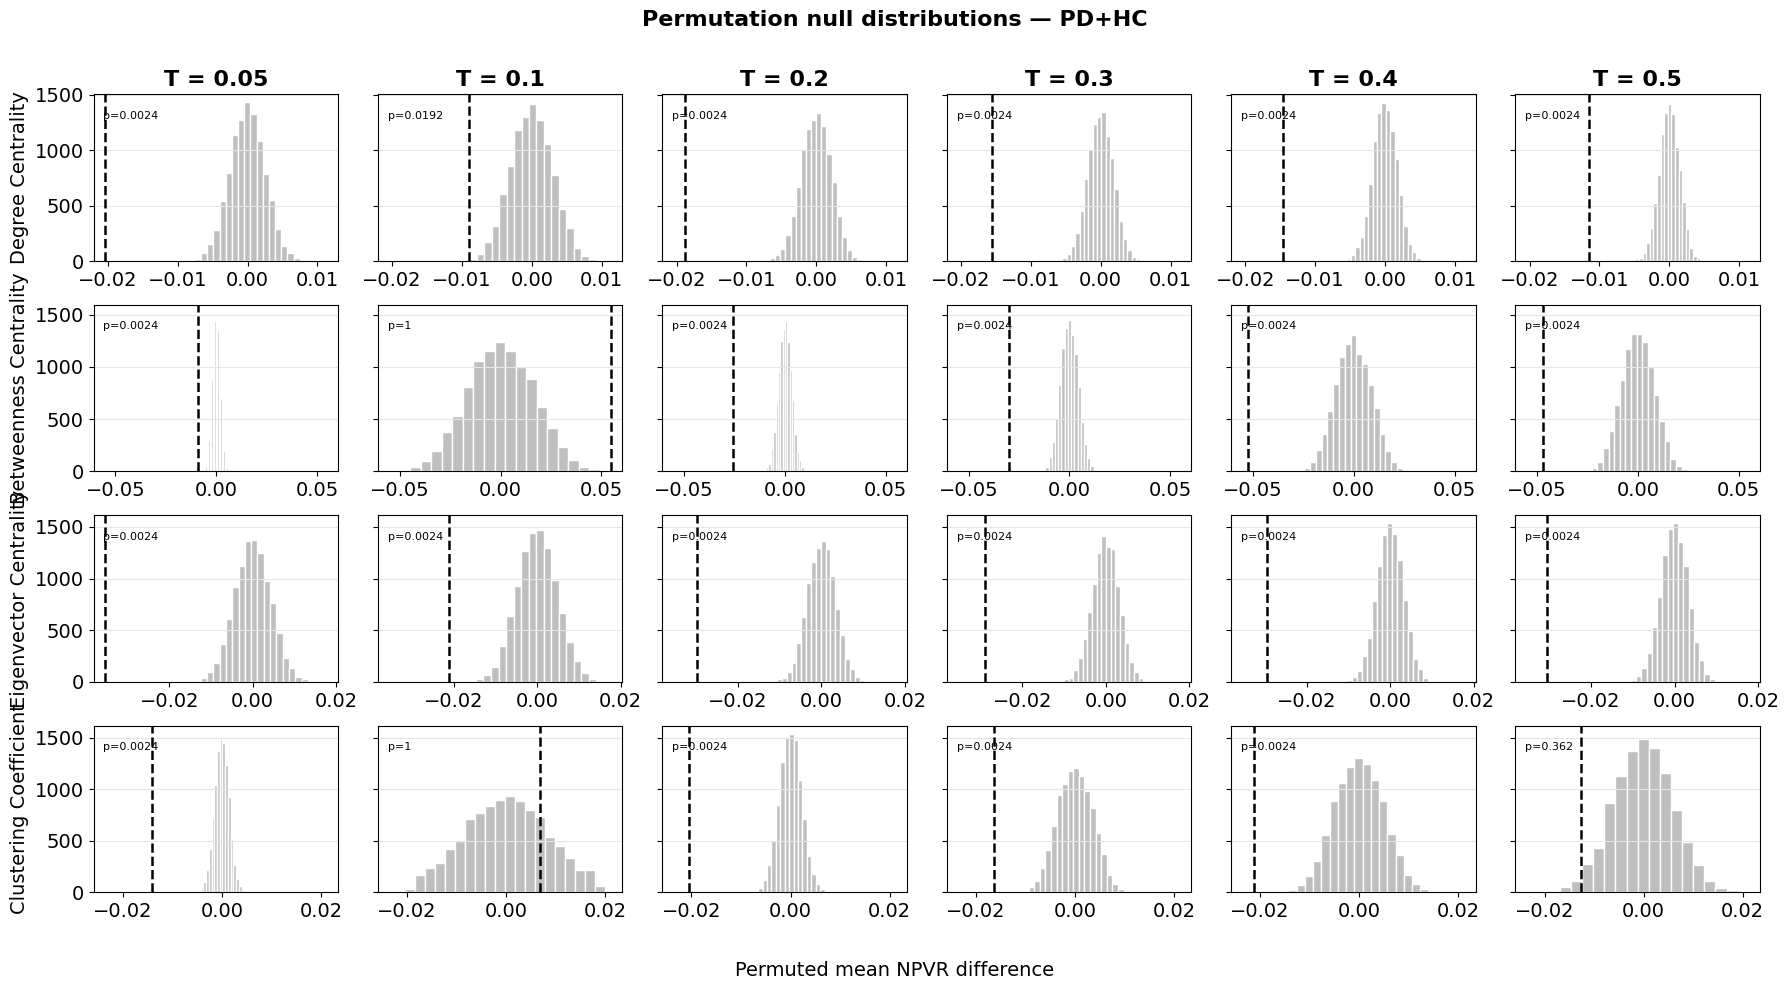

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/permutation-null-pd.tif


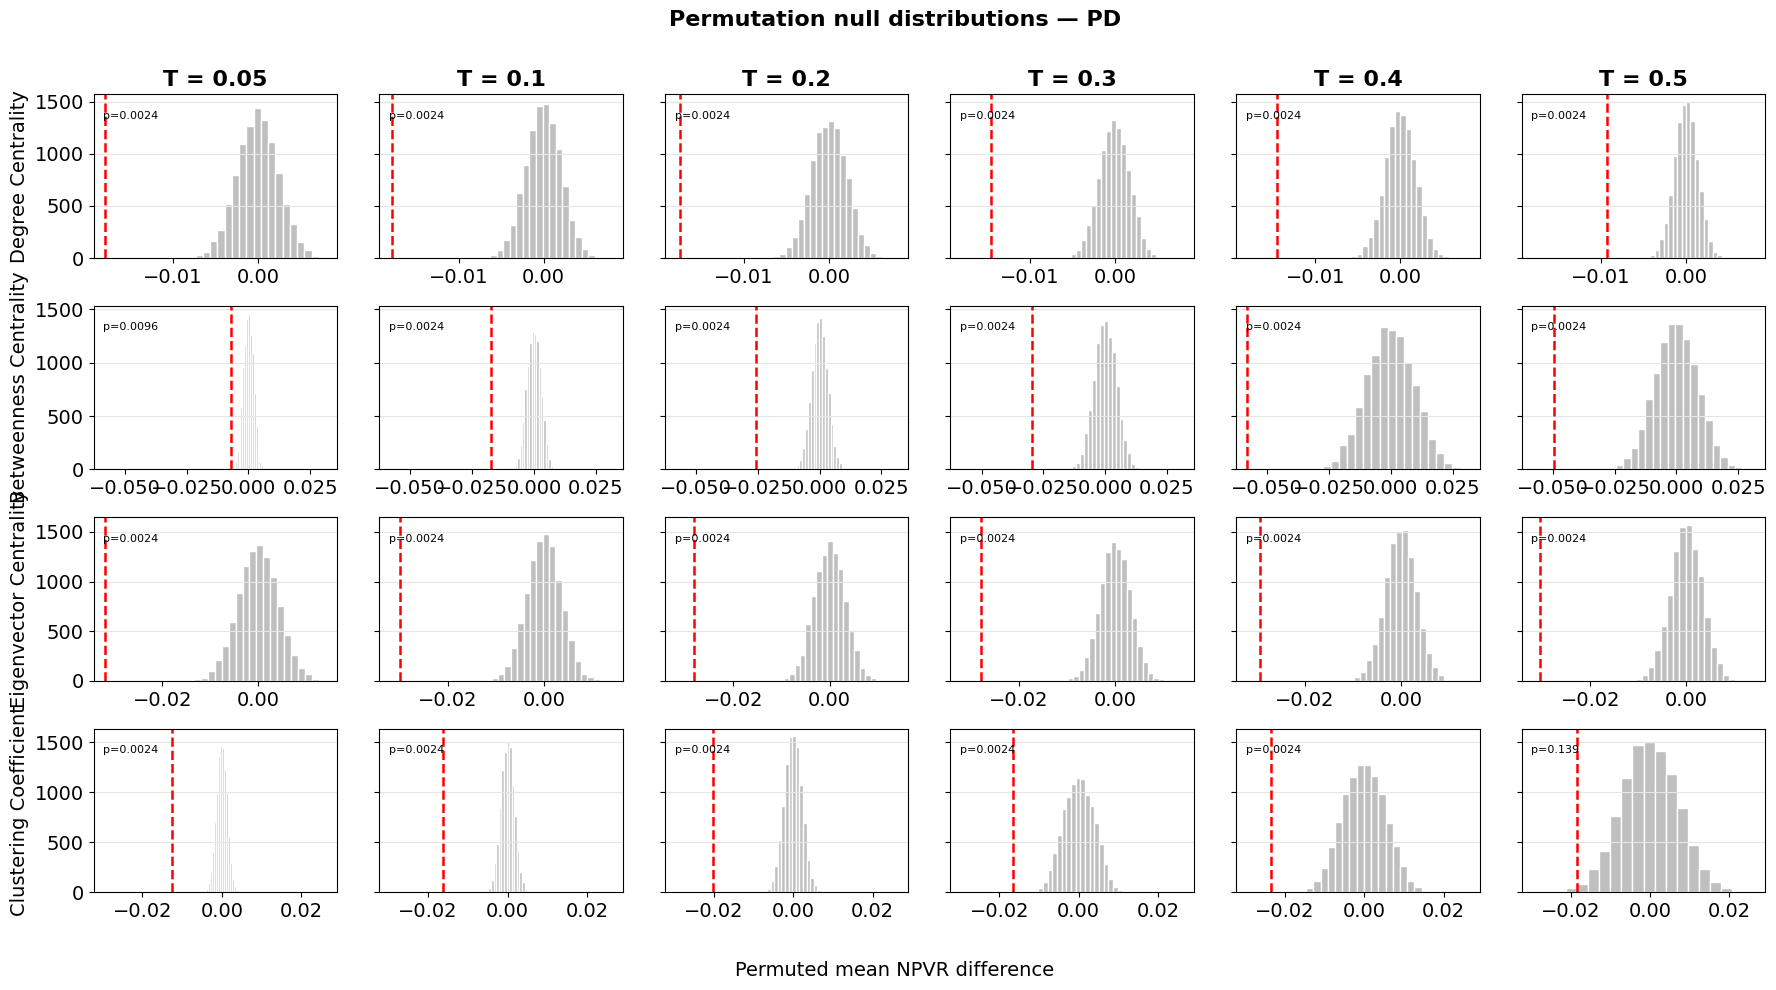

Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig5and6and-Conf_vs_NoConf/permutation-null-hc.tif


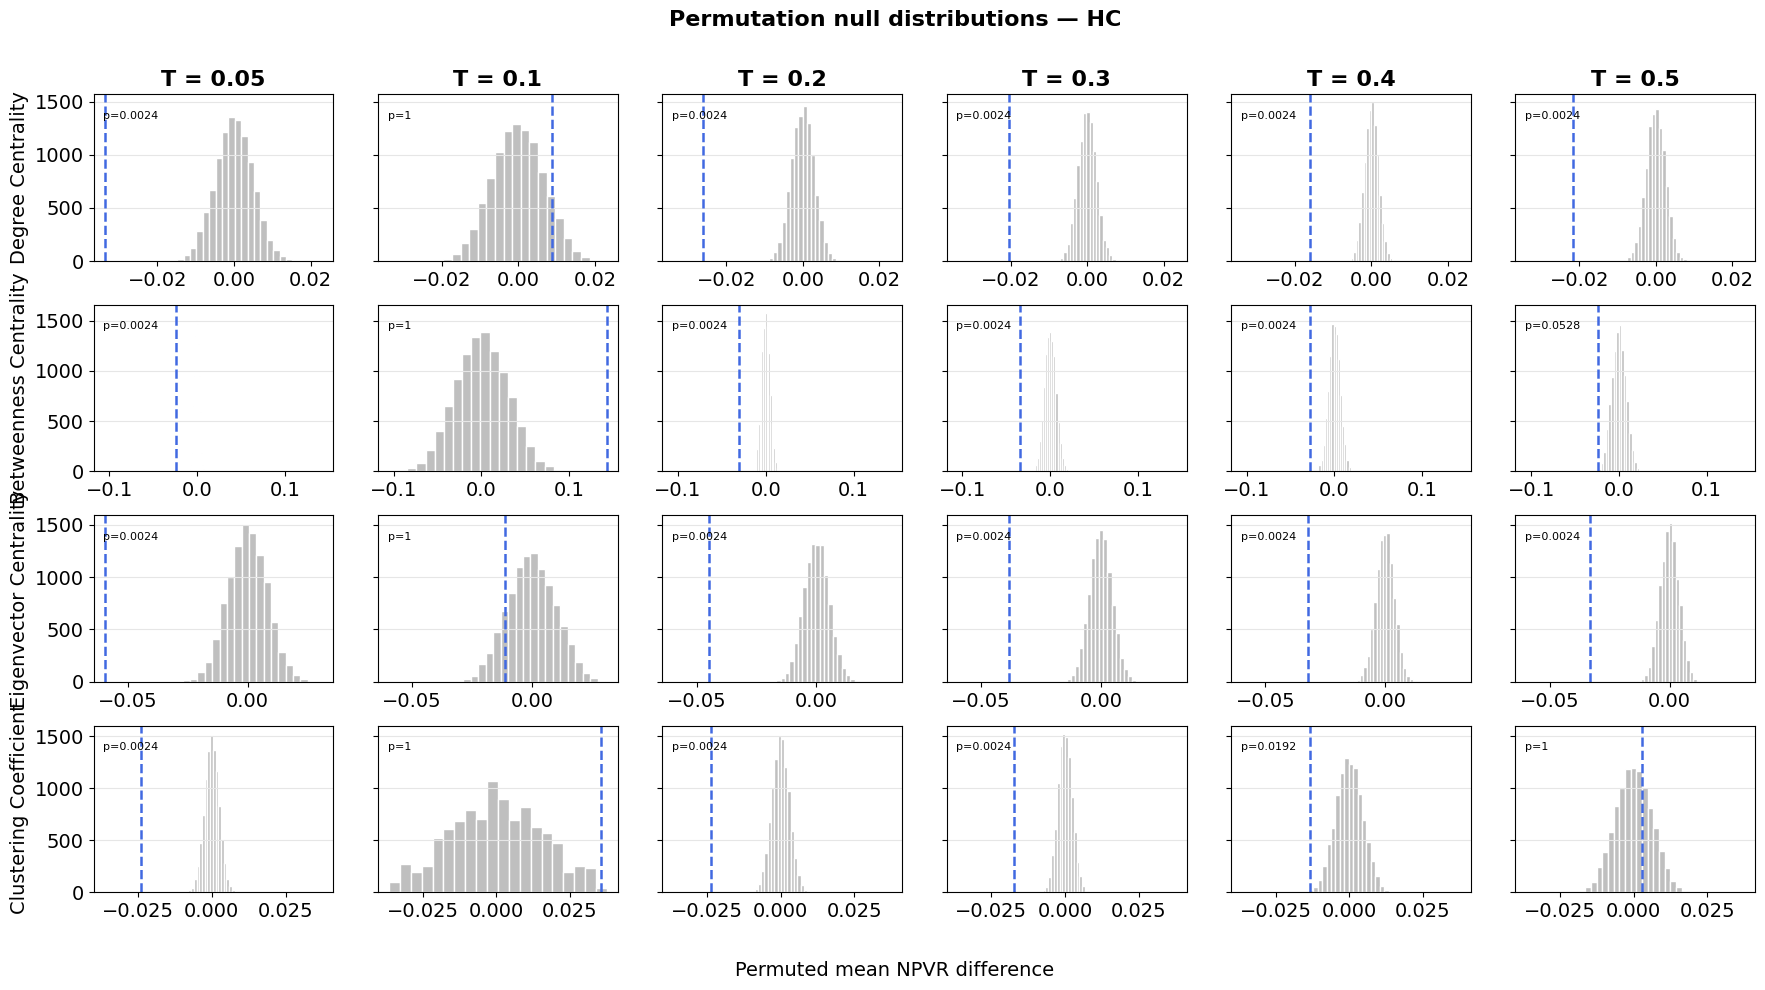

In [11]:
def plot_permutation_diagnostics(group: str) -> plt.Figure:
    figure, axes = plt.subplots(4, 6, figsize=(18, 10), sharex="row", sharey="row")
    for row, (metric, metric_label) in enumerate(LOCAL_METRICS.items()):
        for column, threshold in enumerate(THRESHOLDS):
            axis = axes[row, column]
            result = permutation_results[group][threshold][metric]
            axis.hist(result["null"], bins=20, color="0.75", edgecolor="white")
            axis.axvline(result["statistic"], color=COLORS[group], linestyle="--", linewidth=1.8)
            axis.text(0.04, 0.90, f"p={result['p_corrected']:.3g}",
                      transform=axis.transAxes, fontsize=8, va="top")
            if row == 0: axis.set_title(f"T = {threshold:g}", fontweight="bold", fontsize=16)
            if column == 0: axis.set_ylabel(metric_label, fontsize=14)
            axis.tick_params(axis="both", labelsize=14)
            axis.grid(axis="y", color="0.9", linewidth=0.8)
    figure.suptitle(f"Permutation null distributions — {GROUP_LABELS[group]}", fontweight="bold", fontsize=16)
    figure.supxlabel("Permuted mean NPVR difference", fontsize=14)
    figure.tight_layout(rect=(0, 0.02, 1, 0.97))
    return figure


for group in ("combined", "pd", "hc"):
    diagnostic = plot_permutation_diagnostics(group)
    save_figure(diagnostic, f"permutation-null-{group}")
    plt.show()

![PD+HC permutation diagnostics](Figures/permutation-null-combined.png)

![PD permutation diagnostics](Figures/permutation-null-pd.png)

![HC permutation diagnostics](Figures/permutation-null-hc.png)

## Interpretation guide

- Positive $\Delta\mathrm{NPVR}$ means NPVR is larger without confound regression.
- Positive $\Delta\mathrm{NV}$ or $\Delta\mathrm{PV}$ means variability is larger with confound regression.
- Local-metric boxes summarize the 100 Schaefer regions; global metrics are scalar estimates.
- Corrected permutation labels describe evidence that the regional mean $\Delta\mathrm{NPVR}$ is below zero.